![](images/LeNet-5_arch.jpg)

In [17]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

In [45]:
# load dataset (Hand-write digits)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

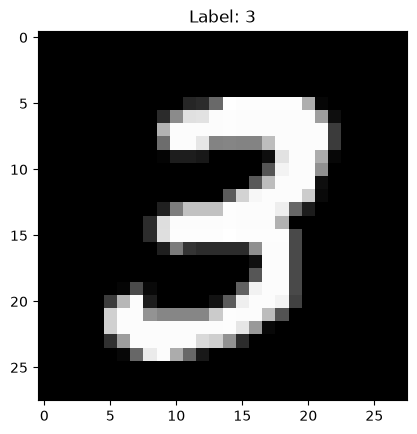

Image Shape: (28, 28, 1) -> That means it's Black&White (one channel)


In [47]:
# You can see the samples :)
sample_index = 7
plt.imshow(x_train[sample_index], cmap="gray")
plt.title(f"Label: {y_train[sample_index]}")
plt.show()
print(f"Image Shape: {x_train[sample_index].shape} -> That means it's Black&White (one channel)")

In [46]:
# Reshape to (Batch, Height, Width, Channels) to explicitly specify 1 grayscale channel
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

<hr>

In [53]:
inputs = layers.Input(shape=(28,28,1))
# Padding, because of original model is 32*32
Scale_data = layers.Rescaling(scale=1.0/255)(inputs)
Padding= layers.ZeroPadding2D(padding=(2,2))(Scale_data)
Conv_1 = layers.Conv2D(filters=6, kernel_size=(5,5), strides=(1,1), activation="relu")(Padding)
Pool_1 = layers.AveragePooling2D(pool_size=2, strides=2)(Conv_1)
Conv_2 = layers.Conv2D(filters=16, kernel_size=(5,5), strides=(1,1), activation="relu")(Pool_1)
Pool_2 = layers.AveragePooling2D(pool_size=2, strides=2)(Conv_2)
Fllaten_l = layers.Flatten()(Pool_2)
FC_1   = layers.Dense(units=120, activation="relu")(Fllaten_l)
FC_2   = layers.Dense(units=84, activation="relu")(FC_1)
# we don't use activation before output
FC_3   = layers.Dense(units=10)(FC_2)
Output = layers.Softmax()(FC_3)

In [54]:
# Instantiate Model
lenet_model = models.Model(inputs=inputs, outputs=Output, name="LeNet-5")

In [55]:
# Check layer shapes and parameter counts
lenet_model.summary()

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_3                │ (None, 32, 32, 1)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_3 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
lenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [57]:
history = lenet_model.fit(
    x = x_train,
    y = y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9167 - loss: 0.2773 - val_accuracy: 0.9695 - val_loss: 0.0964
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9732 - loss: 0.0854 - val_accuracy: 0.9809 - val_loss: 0.0568
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9814 - loss: 0.0606 - val_accuracy: 0.9859 - val_loss: 0.0461
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9867 - val_loss: 0.0425
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9870 - loss: 0.0404 - val_accuracy: 0.9879 - val_loss: 0.0393
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9891 - loss: 0.0335 - val_accuracy: 0.9873 - val_loss: 0.0418
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9911 - loss: 0.0284 - val_accuracy: 0.9884 - val_loss: 0.0352
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9922 - loss: 0.0246 - val_accuracy: 0.

In [59]:
# evaluate
test_loss, test_acc = lenet_model.evaluate(x=x_test, y=y_test, verbose=0)
print(f"Test Accuracy: {test_acc * 100}")

Test Accuracy: 98.76999855041504


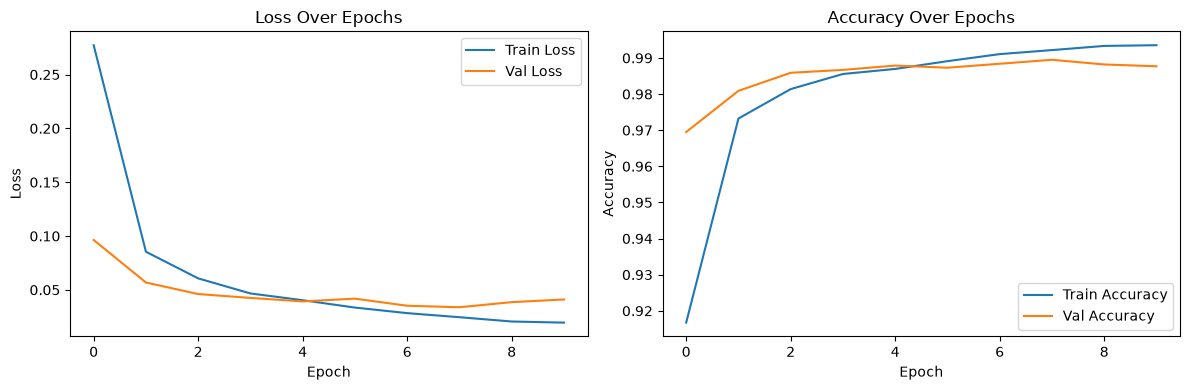

In [71]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()